# Task 1: Data Exploration for Europarl EN-PT

This notebook performs exploratory data analysis (EDA) for the English-Portuguese Europarl corpus.

It includes:
- loading the parallel corpus
- checking sentence-pair counts
- detecting empty lines and XML tag lines
- sentence length statistics
- length distributions and length-ratio analysis
- vocabulary size and frequent words
- random examples
- saving a random 10% sample for later tasks

Expected folder structure:

```text
pt-en/
├── europarl-v7.pt-en.en
└── europarl-v7.pt-en.pt
```


In [5]:
from pathlib import Path
import random
import re
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt

# Change this if your data folder is somewhere else
DATA_DIR = Path("pt-en")

EN_PATH = DATA_DIR / "europarl-v7.pt-en.en"
PT_PATH = DATA_DIR / "europarl-v7.pt-en.pt"

OUTPUT_DIR = Path("outputs_task1")
OUTPUT_DIR.mkdir(exist_ok=True)

print("English file exists:", EN_PATH.exists(), EN_PATH)
print("Portuguese file exists:", PT_PATH.exists(), PT_PATH)

English file exists: True pt-en/europarl-v7.pt-en.en
Portuguese file exists: True pt-en/europarl-v7.pt-en.pt


## 1. Load data

Europarl files can sometimes cause encoding issues. We first try UTF-8 and fall back to Latin-1 if needed.

In [6]:
def read_lines(path: Path):
    """Read a text file and return lines without trailing newline characters."""
    try:
        with open(path, "r", encoding="utf-8") as f:
            return [line.rstrip("\n") for line in f]
    except UnicodeDecodeError:
        with open(path, "r", encoding="latin-1") as f:
            return [line.rstrip("\n") for line in f]

en_lines = read_lines(EN_PATH)
pt_lines = read_lines(PT_PATH)

print("Number of English lines:", len(en_lines))
print("Number of Portuguese lines:", len(pt_lines))
print("Same number of lines:", len(en_lines) == len(pt_lines))

Number of English lines: 1960407
Number of Portuguese lines: 1960407
Same number of lines: True


## 2. Basic corpus statistics

In [7]:
def is_empty(line: str) -> bool:
    return line.strip() == ""

def is_xml_tag(line: str) -> bool:
    return line.strip().startswith("<")

stats = {
    "total_sentence_pairs": len(en_lines),
    "empty_en_lines": sum(is_empty(x) for x in en_lines),
    "empty_pt_lines": sum(is_empty(x) for x in pt_lines),
    "both_empty_lines": sum(is_empty(e) and is_empty(p) for e, p in zip(en_lines, pt_lines)),
    "xml_en_lines": sum(is_xml_tag(x) for x in en_lines),
    "xml_pt_lines": sum(is_xml_tag(x) for x in pt_lines),
    "both_xml_lines": sum(is_xml_tag(e) and is_xml_tag(p) for e, p in zip(en_lines, pt_lines)),
}

stats_df = pd.DataFrame(list(stats.items()), columns=["Statistic", "Value"])
display(stats_df)

stats_df.to_csv(OUTPUT_DIR / "basic_corpus_statistics.csv", index=False)

,Statistic,Value
0,total_sentence_pairs,1960407
1,empty_en_lines,1058
2,empty_pt_lines,2890
3,both_empty_lines,0
4,xml_en_lines,0
5,xml_pt_lines,0
6,both_xml_lines,0


## 3. Clean pairs for exploration

For EDA we remove empty lines and XML tag lines. This is also useful preparation for Task 2.

In [8]:
pairs = []

for en, pt in zip(en_lines, pt_lines):
    if is_empty(en) or is_empty(pt):
        continue
    if is_xml_tag(en) or is_xml_tag(pt):
        continue
    pairs.append((en, pt))

print("Original sentence pairs:", len(en_lines))
print("Clean sentence pairs for EDA:", len(pairs))
print("Removed pairs:", len(en_lines) - len(pairs))

Original sentence pairs: 1960407
Clean sentence pairs for EDA: 1956459
Removed pairs: 3948


## 4. Tokenization and sentence length statistics

For Task 1, simple whitespace tokenization is enough for broad corpus statistics.

In [9]:
def simple_tokenize(text: str):
    return text.strip().split()

en_lengths = [len(simple_tokenize(en)) for en, _ in pairs]
pt_lengths = [len(simple_tokenize(pt)) for _, pt in pairs]

length_df = pd.DataFrame({
    "en_length": en_lengths,
    "pt_length": pt_lengths,
})

length_summary = length_df.describe(percentiles=[0.25, 0.5, 0.75, 0.90, 0.95, 0.99]).T
display(length_summary)

length_summary.to_csv(OUTPUT_DIR / "sentence_length_summary.csv")

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
en_length,1956459.0,25.168885,15.200337,1.0,14.0,22.0,33.0,45.0,53.0,74.0,668.0
pt_length,1956459.0,25.518577,15.646978,1.0,14.0,23.0,33.0,45.0,54.0,75.0,636.0


## 5. Sentence length distribution

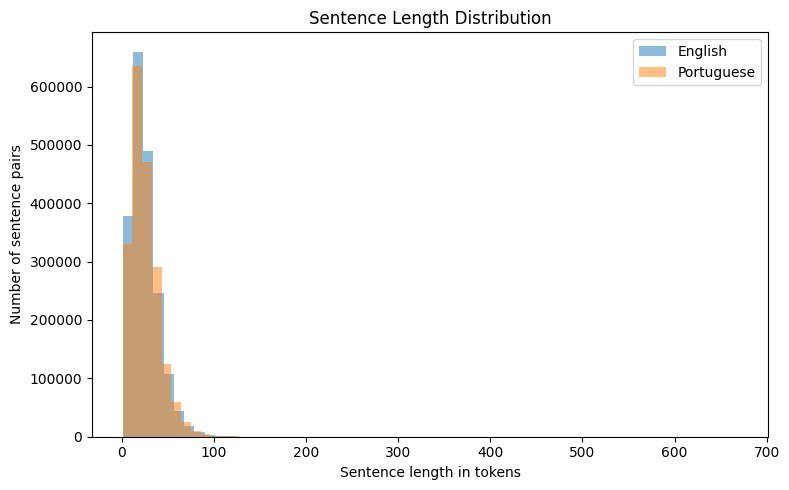

In [11]:
plt.figure(figsize=(8, 5))
plt.hist(en_lengths, bins=60, alpha=0.5, label="English")
plt.hist(pt_lengths, bins=60, alpha=0.5, label="Portuguese")
plt.xlabel("Sentence length in tokens")
plt.ylabel("Number of sentence pairs")
plt.title("Sentence Length Distribution")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "sentence_length_distribution.png", dpi=200)
plt.show()

## 6. English-Portuguese length relationship

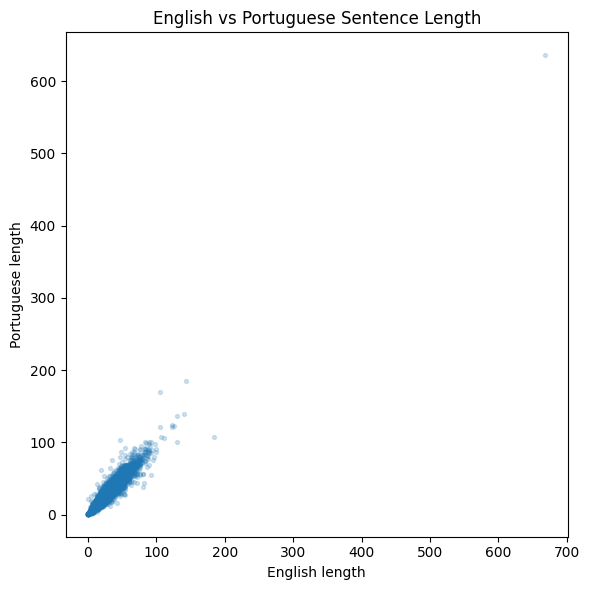

Pearson correlation between EN and PT sentence length: 0.9552


In [13]:
# Scatter plot with a sample to avoid plotting millions of points
sample_size = min(10000, len(length_df))
scatter_df = length_df.sample(sample_size, random_state=42)

plt.figure(figsize=(6, 6))
plt.scatter(scatter_df["en_length"], scatter_df["pt_length"], alpha=0.2, s=8)
plt.xlabel("English length")
plt.ylabel("Portuguese length")
plt.title("English vs Portuguese Sentence Length")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "en_pt_length_scatter.png", dpi=200)
plt.show()

corr = length_df["en_length"].corr(length_df["pt_length"])
print("Pearson correlation between EN and PT sentence length:", round(corr, 4))

## 7. Length ratio analysis

Length ratio is defined as:

$$\text{ratio} = \frac{\text{Portuguese length}}{\text{English length}}$$

count    1.956459e+06
mean     1.025457e+00
std      2.405873e-01
min      1.435407e-02
25%      9.024390e-01
50%      1.000000e+00
75%      1.125000e+00
90%      1.250000e+00
95%      1.360000e+00
99%      1.642857e+00
max      6.300000e+01
Name: pt_en_length_ratio, dtype: float64

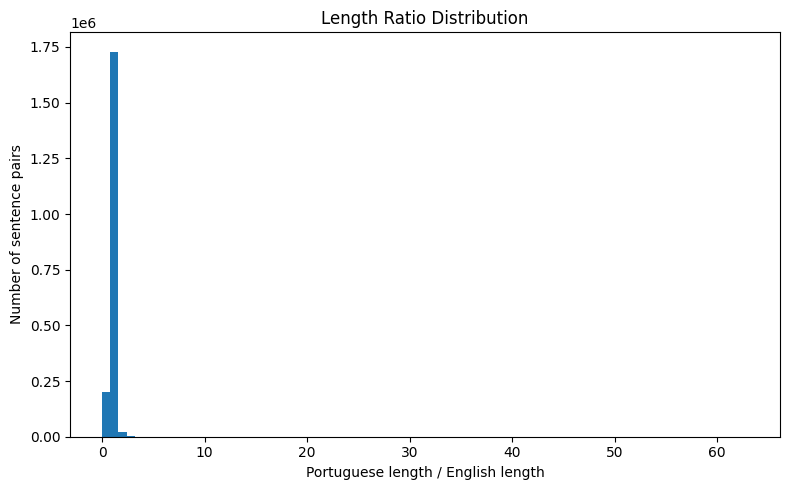

In [14]:
ratio_df = length_df[length_df["en_length"] > 0].copy()
ratio_df["pt_en_length_ratio"] = ratio_df["pt_length"] / ratio_df["en_length"]

display(ratio_df["pt_en_length_ratio"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

plt.figure(figsize=(8, 5))
plt.hist(ratio_df["pt_en_length_ratio"], bins=80)
plt.xlabel("Portuguese length / English length")
plt.ylabel("Number of sentence pairs")
plt.title("Length Ratio Distribution")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "length_ratio_distribution.png", dpi=200)
plt.show()

## 8. Vocabulary size and frequent words

This section lowercases text and removes simple punctuation boundaries for broad frequency analysis.

In [15]:
word_pattern = re.compile(r"\b\w+\b", flags=re.UNICODE)

def words_lower(text: str):
    return word_pattern.findall(text.lower())

en_counter = Counter()
pt_counter = Counter()

for en, pt in pairs:
    en_counter.update(words_lower(en))
    pt_counter.update(words_lower(pt))

vocab_stats = pd.DataFrame({
    "Language": ["English", "Portuguese"],
    "Total tokens": [sum(en_counter.values()), sum(pt_counter.values())],
    "Vocabulary size": [len(en_counter), len(pt_counter)],
})

display(vocab_stats)
vocab_stats.to_csv(OUTPUT_DIR / "vocabulary_statistics.csv", index=False)

,Language,Total tokens,Vocabulary size
0,English,49512637,83837
1,Portuguese,50344369,135751


In [16]:
top_n = 20
top_en = pd.DataFrame(en_counter.most_common(top_n), columns=["word", "count"])
top_pt = pd.DataFrame(pt_counter.most_common(top_n), columns=["word", "count"])

display(top_en)
display(top_pt)

top_en.to_csv(OUTPUT_DIR / "top20_english_words.csv", index=False)
top_pt.to_csv(OUTPUT_DIR / "top20_portuguese_words.csv", index=False)

,word,count
0,the,3778376
1,of,1789501
2,to,1663574
3,and,1419876
4,in,1181316
5,that,903426
6,a,836847
7,is,832386
8,for,576759
9,we,569839


,word,count
0,de,2392034
1,a,2185432
2,que,1671420
3,e,1349164
4,o,1251459
5,da,835757
6,do,718363
7,em,649066
8,os,583788
9,para,554971


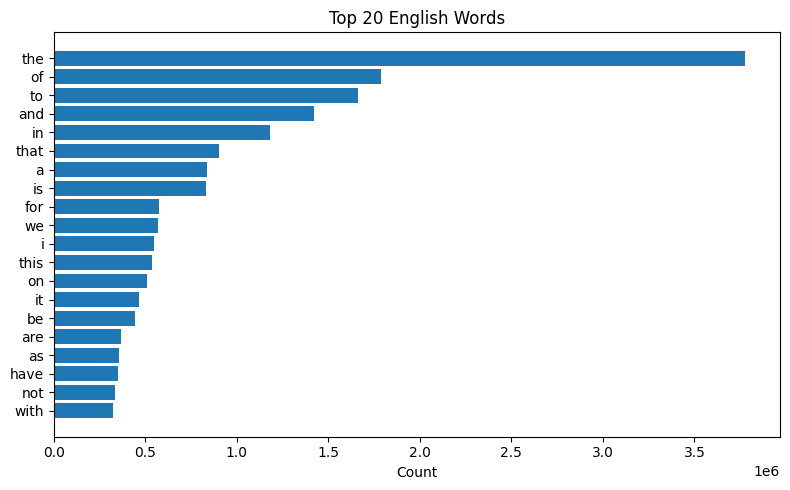

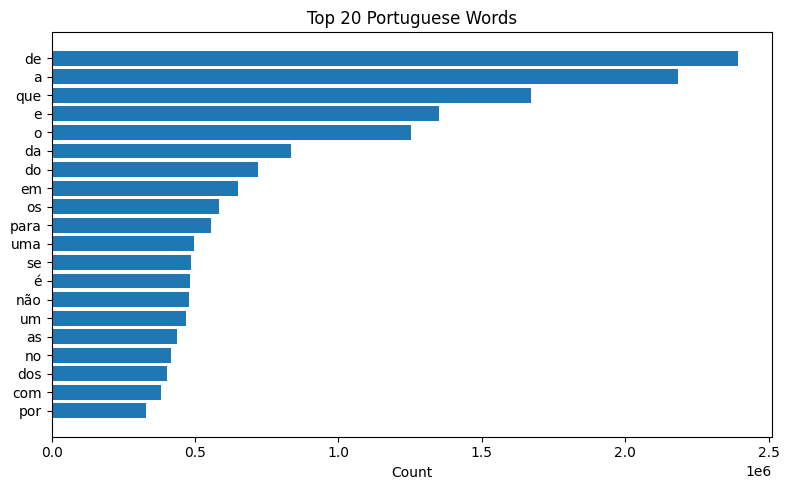

In [17]:
plt.figure(figsize=(8, 5))
plt.barh(top_en["word"][::-1], top_en["count"][::-1])
plt.xlabel("Count")
plt.title("Top 20 English Words")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "top20_english_words.png", dpi=200)
plt.show()

plt.figure(figsize=(8, 5))
plt.barh(top_pt["word"][::-1], top_pt["count"][::-1])
plt.xlabel("Count")
plt.title("Top 20 Portuguese Words")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "top20_portuguese_words.png", dpi=200)
plt.show()

## 9. Random sentence-pair examples

In [18]:
random.seed(42)
example_indices = random.sample(range(len(pairs)), 5)

for i, idx in enumerate(example_indices, start=1):
    en, pt = pairs[idx]
    print(f"Example {i}")
    print("EN:", en)
    print("PT:", pt)
    print("-" * 80)

Example 1
EN: Financial Regulation applicable to the general budget of the European Communities as regards the European External Action Service (
PT: Regulamento Financeiro aplicável ao orçamento geral das Comunidades Europeias no que diz respeito ao Serviço Europeu de Acção Externa (
--------------------------------------------------------------------------------
Example 2
EN: Persons involved in perpetrating any of these awful terrorist attacks which have taken place must be arrested and must be brought to justice, including terrorists operating in the Hamas and Islamic Jihad organisations.
PT: As pessoas envolvidas na execução de qualquer dos hediondos ataques terroristas que tiveram lugar deverão ser detidas e julgadas, incluído os terroristas que operam no seio das organizações do Hamas e da Jihad Islâmica.
--------------------------------------------------------------------------------
Example 3
EN: In this European Parliament report, the rapporteur makes some criticisms of the a

## 10. Random 10% sampling for later tasks

The project asks us to randomly select 10% of the data for training models in the next steps. We use a fixed random seed for reproducibility.

In [19]:
random.seed(42)

n_sample = int(0.10 * len(pairs))
sample_indices = random.sample(range(len(pairs)), n_sample)
sample_pairs = [pairs[i] for i in sample_indices]

print("Clean pairs:", len(pairs))
print("10% sampled pairs:", len(sample_pairs))

sample_en_path = OUTPUT_DIR / "sample_10_percent.en"
sample_pt_path = OUTPUT_DIR / "sample_10_percent.pt"

with open(sample_en_path, "w", encoding="utf-8") as f_en, open(sample_pt_path, "w", encoding="utf-8") as f_pt:
    for en, pt in sample_pairs:
        f_en.write(en + "\n")
        f_pt.write(pt + "\n")

print("Saved:", sample_en_path)
print("Saved:", sample_pt_path)

Clean pairs: 1956459
10% sampled pairs: 195645
Saved: outputs_task1/sample_10_percent.en
Saved: outputs_task1/sample_10_percent.pt


## 11. Suggested report findings

After running the notebook, write your own numbers into the report. Useful findings usually include:

1. The corpus contains the same number of English and Portuguese lines, confirming parallel alignment at file level.
2. Some lines are empty or XML/meta-information lines, so they should be removed before model training.
3. English and Portuguese sentence lengths are strongly correlated, which is expected for a parallel corpus.
4. Portuguese sentences may be slightly longer/shorter on average depending on tokenization; report the actual mean and median.
5. Very long sentences exist and may make model training harder; later preprocessing can optionally filter extreme lengths.
6. The random 10% sample is saved and should be used for the next tasks.
